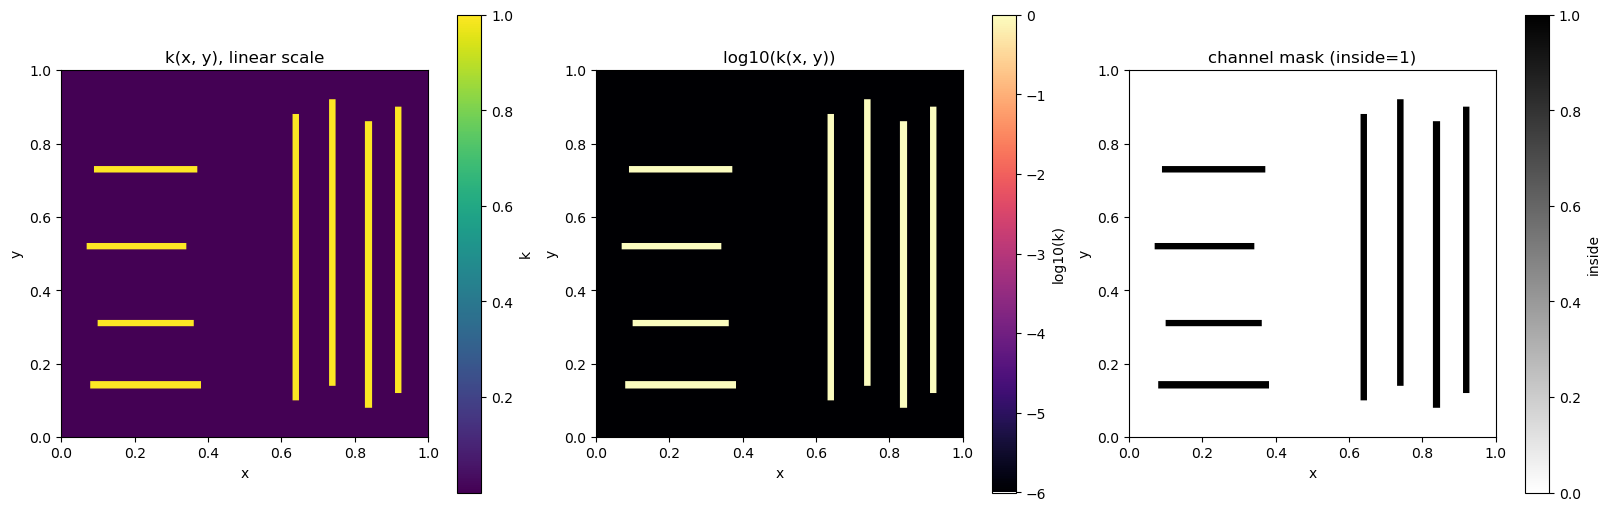

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def diffusion_coeff_channel(x, y):
    k_inside = 1.0
    k_outside = 1.0e-6
    half_width = 0.03
    centers = np.array([0.25, 0.5, 0.75])

    inside = np.zeros_like(x, dtype=bool)
    for c in centers:
        inside |= (np.abs(y - c) <= half_width) | (np.abs(x - c) <= half_width)

    return np.where(inside, k_inside, k_outside)


n = 401
grid = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(grid, grid, indexing="xy")
K = diffusion_coeff_channel(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(
    K,
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    cmap="viridis",
    vmin=1.0e-6,
    vmax=1.0,
)
axes[0].set_title("k(x, y) linear scale")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], label="k")

im1 = axes[1].imshow(
    np.log10(K),
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    cmap="magma",
)
axes[1].set_title("log10(k(x, y))")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], label="log10(k)")

plt.show()

Saved: /home/ET/yjzhou/projects/Algebraic_CEM/script/coefficient_inclusions.png


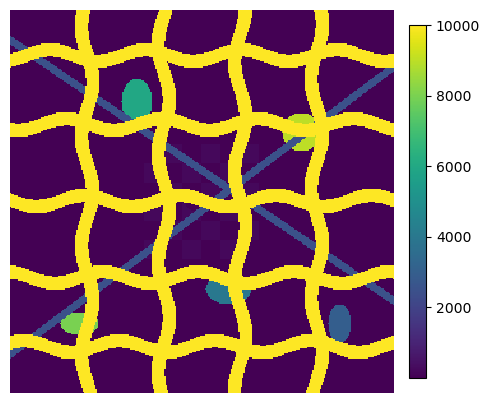

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def diffusion_coeff_inclusions(x, y):
    k_background = 1.0
    k_channel = 1.0e4
    k_fracture = 2.5e3
    k_low = 2.0e-1

    horizontal_centers = np.array([0.12, 0.30, 0.50, 0.70, 0.88])
    vertical_centers = np.array([0.20, 0.40, 0.60, 0.80])

    inclusions = [
        (0.18, 0.18, 0.05, 0.03, 8.0e3),
        (0.33, 0.76, 0.04, 0.06, 6.0e3),
        (0.57, 0.27, 0.06, 0.04, 4.0e3),
        (0.76, 0.68, 0.05, 0.05, 9.0e3),
        (0.86, 0.18, 0.03, 0.05, 3.0e3),
        (0.48, 0.50, 0.025, 0.025, k_low),
    ]

    k = np.full_like(x, k_background, dtype=float)
    occupied = np.zeros_like(x, dtype=bool)

    # Priority order matches the C++ implementation.
    for c in horizontal_centers:
        wiggle = 0.015 * np.sin(8.0 * np.pi * x + 6.0 * c)
        mask = np.abs(y - (c + wiggle)) <= 0.018
        k[mask] = k_channel
        occupied |= mask

    for c in vertical_centers:
        wiggle = 0.015 * np.cos(7.0 * np.pi * y + 5.0 * c)
        mask = np.abs(x - (c + wiggle)) <= 0.018
        k[mask] = k_channel
        occupied |= mask

    fracture_mask = (
        (np.abs(y - (0.10 + 0.75 * x)) <= 0.012)
        | (np.abs(y - (0.92 - 0.68 * x)) <= 0.012)
    ) & (~occupied)
    k[fracture_mask] = k_fracture
    occupied |= fracture_mask

    for cx, cy, rx, ry, kval in inclusions:
        ell_mask = ((x - cx) / rx) ** 2 + ((y - cy) / ry) ** 2 <= 1.0
        mask = ell_mask & (~occupied)
        k[mask] = kval
        occupied |= mask

    checker_patch = (
        (x > 0.35)
        & (x < 0.65)
        & (y > 0.35)
        & (y < 0.65)
        & (~occupied)
    )
    ix = np.floor((x - 0.35) / 0.05).astype(int)
    iy = np.floor((y - 0.35) / 0.05).astype(int)
    checker_vals = np.where(((ix + iy) % 2) == 0, 2.0e2, 5.0)
    k[checker_patch] = checker_vals[checker_patch]

    return k


n = 301
grid = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(grid, grid, indexing="xy")
K = diffusion_coeff_inclusions(X, Y)

fig, ax = plt.subplots(figsize=(4.8, 4.8), constrained_layout=True)
im = ax.imshow(
    K,
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    cmap="viridis",
    vmin=2.0e-1,
    vmax=1.0e4,
    interpolation="nearest",
)
ax.axis("off")

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

output_path = Path("/home/ET/yjzhou/projects/Algebraic_CEM/script/coefficient_inclusions.png")
fig.savefig(output_path, dpi=160, transparent=True, bbox_inches="tight", pad_inches=0.02)
print(f"Saved: {output_path}")

plt.show()

Saved: /home/ET/yjzhou/projects/Algebraic_CEM/script/coefficient_multichannel_complex.png


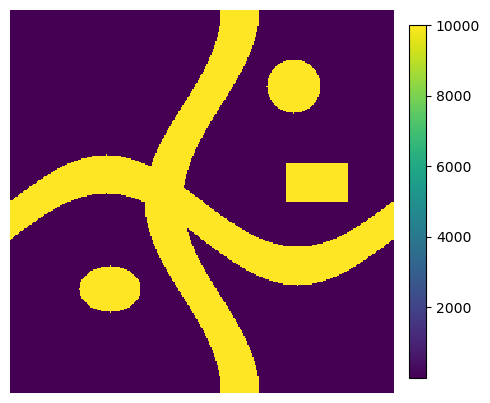

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def diffusion_coeff_multichannel_complex(x, y):
    k_background = 1.0
    k_high = 1.0e4

    # Match the current C++ coefficient in newsrc/cem.cc.
    y_channel = 0.45 + 0.12 * np.sin(2.0 * np.pi * x)
    x_channel = 0.50 + 0.10 * np.cos(2.0 * np.pi * y)

    k = np.full_like(x, k_background, dtype=float)

    channel_mask = (np.abs(y - y_channel) <= 0.050) | (np.abs(x - x_channel) <= 0.050)
    k[channel_mask] = k_high

    inclusions = [
        (0.26, 0.27, 0.080, 0.060),
        (0.74, 0.80, 0.070, 0.070),
    ]
    for cx, cy, rx, ry in inclusions:
        ell_mask = ((x - cx) / rx) ** 2 + ((y - cy) / ry) ** 2 <= 1.0
        k[ell_mask] = k_high

    branch_mask = (x >= 0.72) & (x <= 0.88) & (y >= 0.50) & (y <= 0.60)
    k[branch_mask] = k_high

    return k


n = 301
grid = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(grid, grid, indexing="xy")
K = diffusion_coeff_multichannel_complex(X, Y)

fig, ax = plt.subplots(figsize=(4.8, 4.8), constrained_layout=True)
im = ax.imshow(
    K,
    origin="lower",
    extent=[0.0, 1.0, 0.0, 1.0],
    cmap="viridis",
    vmin=1.0,
    vmax=1.0e4,
    interpolation="nearest",
)
ax.axis("off")

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

output_path = Path("/home/ET/yjzhou/projects/Algebraic_CEM/script/coefficient_multichannel_complex.png")
fig.savefig(output_path, dpi=160, transparent=True, bbox_inches="tight", pad_inches=0.02)
print(f"Saved: {output_path}")

plt.show()